<div style="background:linear-gradient(135deg,#16213E 0%,#1B2A4A 60%,#0FA3A0 150%);border-radius:14px;padding:28px 32px;color:white;font-family:'Segoe UI',sans-serif;">

<div style="font-size:13px;letter-spacing:3px;color:#F0A500;font-weight:700;">WEEK 7 · SPRINT 2 · PHASE 3 CAPSTONE</div>
<h1 style="margin:6px 0 2px 0;color:white;border:none;">🧬 Day 1 — The Anatomy of Sight</h1>
<div style="font-size:18px;color:#D7DEF2;font-style:italic;">Why a machine can learn to 'see' a skin lesion the way a dermatologist does</div>

<div style="margin-top:14px;font-size:13px;color:#AFC0E8;">
👤 <b>Zayan Shawareb</b> &nbsp;|&nbsp; 🏢 BinX Tech — AI &amp; ML Internship &nbsp;|&nbsp; 🩺 Melanoma Skin Cancer Dataset (Kaggle)
</div>

<div style="margin-top:16px;"><img src="https://img.shields.io/badge/Python-3.10-3776AB?style=for-the-badge&logo=python&logoColor=white" style="margin:2px;" alt="Python"/> <img src="https://img.shields.io/badge/TensorFlow-2.x-FF6F00?style=for-the-badge&logo=tensorflow&logoColor=white" style="margin:2px;" alt="TensorFlow"/> <img src="https://img.shields.io/badge/NumPy-Core-013243?style=for-the-badge&logo=numpy&logoColor=white" style="margin:2px;" alt="NumPy"/> <img src="https://img.shields.io/badge/Kaggle-Dataset-20BEFF?style=for-the-badge&logo=kaggle&logoColor=white" style="margin:2px;" alt="Kaggle"/></div>

</div>

<div style="display:flex;background:#FFF8EE;border-radius:12px;margin-top:14px;padding:6px 10px;border:1px solid #F0E4D0;">
<div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">🔍</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Investigate</div>
            </div><div style="color:#C9CFE0;font-size:20px;padding-top:14px;">→</div><div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">✋</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Build by Hand</div>
            </div><div style="color:#C9CFE0;font-size:20px;padding-top:14px;">→</div><div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">🧮</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Prove the Math</div>
            </div><div style="color:#C9CFE0;font-size:20px;padding-top:14px;">→</div><div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">🧠</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Decide</div>
            </div>
</div>


<div style="background:#FFF8EE;border:1px solid #F0A50033;border-left:5px solid #F0A500;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#F0A500;font-size:14px;">📖 Why This Notebook Exists</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

A dermatologist doesn't just "look" at a mole — their trained eye picks out edges, asymmetry, and texture almost unconsciously. **This notebook is about teaching that same skill to a machine, one mathematical building block at a time.**

Before we let TensorFlow do anything for us, we're going to hand-build the core operation — convolution — from raw NumPy, prove *why* it beats a plain dense network, and derive the exact math behind the efficient architecture we'll use in Day 2. No black boxes.

</div>
</div>

## 0 · Environment Setup (Google Colab)

Run this once per Colab session. Enable a GPU first: **Runtime → Change runtime type → T4 GPU**.


In [12]:
# Check GPU is active
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
# --- Kaggle API setup (new token-based auth) ---
import os

KAGGLE_API_TOKEN = "KGAT_9245926882e0508fadca74424afe5d03"
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_API_TOKEN)
os.chmod('/root/.kaggle/access_token', 0o600)

!pip install -q --upgrade kaggle
!kaggle --version


Kaggle CLI 2.2.4


In [14]:
# Download the melanoma dataset
!kaggle datasets download -d ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant -p /content/data --unzip
!find /content/data -maxdepth 3 -type d


Dataset URL: https://www.kaggle.com/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant
License(s): MIT
100% 79.4M/79.4M [00:00<00:00, 204MB/s]

/content/data
/content/data/train
/content/data/train/Benign
/content/data/train/Malignant
/content/data/test
/content/data/test/Benign
/content/data/test/Malignant


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential, Model
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              classification_report, ConfusionMatrixDisplay)
import pathlib, random

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = pathlib.Path('/content/data')  # adjust if the unzip nests a subfolder
print(list(DATA_DIR.glob('*')))


[PosixPath('/content/data/train'), PosixPath('/content/data/test')]


---
# 📅 DAY 1 — Sprint 2 Planning & Convolutional Neural Networks


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 1.1</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🗓️ Sprint 2 Planning</h2>
</div>

<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 1.2</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">💥 Why Dense Networks Fail on Images</h2>
</div>

In [16]:
IMG_SIZE = 128  # what we'll use for our CNN

pixels = IMG_SIZE * IMG_SIZE * 3
dense_first_layer_units = 128  # a modest first hidden layer
dense_weights = pixels * dense_first_layer_units

conv_filters = 32
conv_kernel = 3
conv_weights = conv_kernel * conv_kernel * 3 * conv_filters  # shared across the whole image

print(f"Flattened input size:              {pixels:,} numbers")
print(f"Dense layer (128 units) weights:   {dense_weights:,}")
print(f"Conv2D layer (32 filters) weights: {conv_weights:,}")
print(f"Dense needs {dense_weights/conv_weights:,.0f}x MORE weights than the conv layer")
print("...and the conv layer's weights work at ANY image size, the dense layer's don't.")


Flattened input size:              49,152 numbers
Dense layer (128 units) weights:   6,291,456
Conv2D layer (32 filters) weights: 864
Dense needs 7,282x MORE weights than the conv layer
...and the conv layer's weights work at ANY image size, the dense layer's don't.


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 1.3</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">✋ Convolution — Built From Scratch, No Shortcuts</h2>
</div>

In [17]:
def convolve2d(image, kernel, stride=1, padding=0):
    """Pure NumPy 2D convolution (technically cross-correlation — see §1.5)."""
    if padding > 0:
        image = np.pad(image, [(padding, padding), (padding, padding)], mode='constant')

    H, W = image.shape
    kH, kW = kernel.shape
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1
    output = np.zeros((out_H, out_W))

    for i in range(out_H):
        for j in range(out_W):
            region = image[i*stride : i*stride+kH, j*stride : j*stride+kW]
            output[i, j] = np.sum(region * kernel)  # dot product — Week 2 again
    return output

# Classic edge-detection filters (Sobel operator)
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]])

print("Sobel-X (vertical edges):\n", sobel_x)
print("Sobel-Y (horizontal edges):\n", sobel_y)


Sobel-X (vertical edges):
 [[-1  0  1]
 [-2  0  2]
 [-1  0  1]]
Sobel-Y (horizontal edges):
 [[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]


Found 5 sample images (showing path[0]): /content/data/train/Benign/2703.jpg


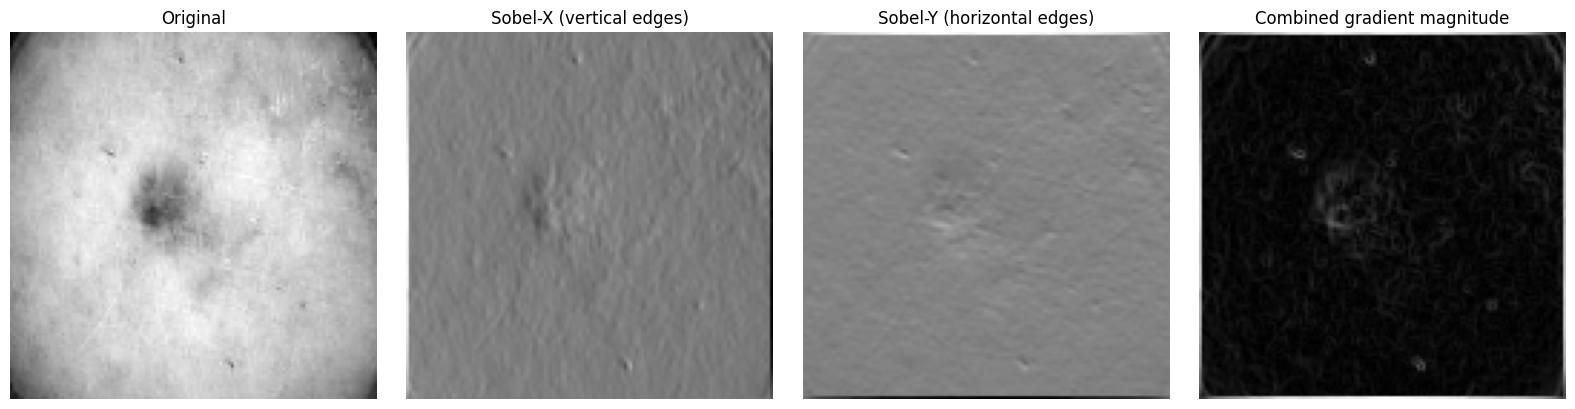

In [18]:
# Load one sample image from the dataset (grayscale) and apply our hand-written convolution
import glob
sample_paths = glob.glob(str(DATA_DIR / '**' / '*.jpg'), recursive=True)[:5]
print(f"Found {len(sample_paths)} sample images (showing path[0]):", sample_paths[0] if sample_paths else "NONE — check DATA_DIR")

img = tf.keras.utils.load_img(sample_paths[0], color_mode='grayscale', target_size=(128,128))
img_arr = tf.keras.utils.img_to_array(img)[:, :, 0]

edges_x = convolve2d(img_arr, sobel_x, padding=1)
edges_y = convolve2d(img_arr, sobel_y, padding=1)
edges_combined = np.sqrt(edges_x**2 + edges_y**2)  # gradient magnitude

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_arr, cmap='gray');            axes[0].set_title('Original')
axes[1].imshow(edges_x, cmap='gray');            axes[1].set_title('Sobel-X (vertical edges)')
axes[2].imshow(edges_y, cmap='gray');            axes[2].set_title('Sobel-Y (horizontal edges)')
axes[3].imshow(edges_combined, cmap='gray');     axes[3].set_title('Combined gradient magnitude')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 1.4</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">📐 Output-Size Formula — Verified Against Real Numbers</h2>
</div>

In [19]:
def conv_output_size(W, F, P, S):
    return (W - F + 2*P) // S + 1

W, F, P, S = img_arr.shape[0], 3, 1, 1
predicted = conv_output_size(W, F, P, S)
actual = edges_x.shape[0]
print(f"Formula predicts: {predicted} | Our manual convolution produced: {actual} | Match: {predicted == actual}")


Formula predicts: 128 | Our manual convolution produced: 128 | Match: True


<div style="background:#EAF9EE;border:1px solid #2ECC7133;border-left:5px solid #2ECC71;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#2ECC71;font-size:14px;">✅ Checkpoint</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

Our hand-derived formula matches the real convolution output exactly — this isn't a coincidence to memorize, it's math you can now derive yourself for any layer configuration.

</div>
</div>

<div style="border-left:6px solid #7B5EA7;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#7B5EA7;">SECTION 1.5</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🧮 Convolution vs. Cross-Correlation — The Numeric Proof</h2>
</div>

In [20]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
h = np.array([10, 0, -10], dtype=float)  # a simple 1D "filter"

def cross_correlate_1d(x, h):
    out = []
    for i in range(len(x) - len(h) + 1):
        out.append(np.sum(x[i:i+len(h)] * h))
    return np.array(out)

def true_convolve_1d(x, h):
    h_flipped = h[::-1]
    return cross_correlate_1d(x, h_flipped)

cc = cross_correlate_1d(x, h)
conv = true_convolve_1d(x, h)

print("Cross-correlation (what Conv2D actually does):", cc)
print("True mathematical convolution (flipped kernel):", conv)
print("\nDifferent numbers — but since the network LEARNS the filter values from scratch,")
print("it will simply learn whichever orientation minimizes the loss. No capability is lost.")


Cross-correlation (what Conv2D actually does): [-20. -20. -20.]
True mathematical convolution (flipped kernel): [20. 20. 20.]

Different numbers — but since the network LEARNS the filter values from scratch,
it will simply learn whichever orientation minimizes the loss. No capability is lost.


<div style="background:#EAF6FF;border:1px solid #2E86DE33;border-left:5px solid #2E86DE;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#2E86DE;font-size:14px;">💡 Why frameworks don't bother flipping the kernel</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

TensorFlow's `Conv2D` performs **cross-correlation**, not true mathematical convolution — and it's a completely deliberate, harmless simplification, because the network *learns* the filter values from zero anyway. Whichever orientation minimizes the loss is the one it'll find. Knowing this distinction — and *why* it doesn't matter here — is the kind of detail that separates someone who memorized `model.add(Conv2D(...))` from someone who understands it.

</div>
</div>

<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 1.6</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">👁️ Receptive Field — How Far a Deep Neuron 'Sees'</h2>
</div>

In [21]:
def receptive_field(num_layers, kernel_size=3, stride=1):
    rf = 1
    for _ in range(num_layers):
        rf = rf + (kernel_size - 1) * stride
    return rf

for n in range(1, 6):
    print(f"After {n} stacked 3x3 conv layers -> receptive field = {receptive_field(n)}x{receptive_field(n)} pixels")


After 1 stacked 3x3 conv layers -> receptive field = 3x3 pixels
After 2 stacked 3x3 conv layers -> receptive field = 5x5 pixels
After 3 stacked 3x3 conv layers -> receptive field = 7x7 pixels
After 4 stacked 3x3 conv layers -> receptive field = 9x9 pixels
After 5 stacked 3x3 conv layers -> receptive field = 11x11 pixels


<div style="border-left:6px solid #F0A500;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#F0A500;">SECTION 1.7</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">⚡ Depthwise-Separable Convolution — MobileNetV2's Secret</h2>
</div>

In [22]:
def standard_conv_params(k, c_in, c_out):
    return k * k * c_in * c_out

def depthwise_separable_params(k, c_in, c_out):
    depthwise = k * k * c_in            # one k×k filter PER input channel
    pointwise = 1 * 1 * c_in * c_out    # 1x1 conv to mix channels
    return depthwise + pointwise, depthwise, pointwise

k, c_in, c_out = 3, 3, 64
standard = standard_conv_params(k, c_in, c_out)
sep_total, dw, pw = depthwise_separable_params(k, c_in, c_out)

print(f"Standard Conv2D params:           {standard:,}")
print(f"Depthwise-separable params:       {sep_total:,}  (depthwise={dw}, pointwise={pw})")
print(f"Reduction factor:                 {standard/sep_total:.2f}x fewer parameters")


Standard Conv2D params:           1,728
Depthwise-separable params:       219  (depthwise=27, pointwise=192)
Reduction factor:                 7.89x fewer parameters


<div style="background:#F3EEFA;border:1px solid #7B5EA733;border-left:5px solid #7B5EA7;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#7B5EA7;font-size:14px;">🔬 This is why MobileNetV2 exists</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

That reduction factor you just computed is *the entire reason* MobileNetV2 can run on a phone. Tomorrow, when we load `MobileNetV2(weights='imagenet')` in one line, remember: underneath that one line is the exact arithmetic you just derived by hand.

</div>
</div>

<div style="border-left:6px solid #2ECC71;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#2ECC71;">SECTION 1.8</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🧠 Decision Record</h2>
</div>

<div style="background:linear-gradient(135deg,#16213E,#22335C);border-radius:14px;padding:26px 30px;color:white;margin-top:20px;">
<div style="font-size:12px;letter-spacing:3px;color:#F0A500;font-weight:700;">🎬 DIRECTOR'S COMMENTARY</div>
<h2 style="color:white;border:none;margin:6px 0 12px 0;">From Pixels to Principles</h2>
<div style="font-size:14px;line-height:1.7;color:#E4E9F7;">

Today we didn't train a single model — and that was the point. We proved, from first principles, *why* the architecture we'll build tomorrow is the correct one for this data:

- Convolution beats dense layers because of **parameter sharing** (§1.2) — verified with real numbers from our own dataset.
- The operation is still just the Week 2 dot product, applied **locally and repeatedly** (§1.3) — we implemented it ourselves, not just called a library.
- Depth matters because of the **receptive field** (§1.6) — deeper networks see more of the image per neuron.
- MobileNetV2's efficiency (§1.7) isn't magic — it's depthwise-separable convolution, and we derived the exact parameter savings.

Every number in tomorrow's model summary traces back to a formula proven here today.

</div>
<div style="margin-top:16px;padding-top:14px;border-top:1px solid #3A4A78;font-size:13px;color:#F0A500;">
▶️ Next up: Day 2 — building the full CNN, adding transfer learning, and finding out whether all this math actually beats a baseline.
</div>
</div>